# 03 - Cross-validation against an independent reference

DPSpice is only trustworthy if it agrees with an *independent* simulator. This
notebook cross-validates the bundled half-wave rectifier against a reference and
reports NRMSE and R-squared per node.

It prefers an **ngspice** run driven automatically (`validate(ref=None)`), but
ngspice is an external binary that may not be installed. So when ngspice is
absent it **falls back to the bundled LTspice `.raw`** that ships with the
package - the notebook runs either way, with no external setup.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import dpspice
from dpspice.examples import example_path
from dpspice._ngspice import ngspice_available
from dpspice.plotting import use_style, PALETTE, table
use_style()

netlist = dpspice.example_text("rectifier_halfwave.sp")
ckt = dpspice.load(netlist)

if ngspice_available():
    print("ngspice found - validating against an auto-generated ngspice run.")
    val = ckt.validate(ref=None)
else:
    print("ngspice not found - falling back to the bundled LTspice .raw reference.")
    with example_path("rectifier_halfwave.raw") as raw:
        val = ckt.validate(ref=raw)

print("reference engine :", val.reference_engine)
print("worst-node NRMSE : %.3e" % val.worst_nrmse)
print("minimum R^2      : %.6f" % val.min_r2)


ngspice found - validating against an auto-generated ngspice run.


reference engine : ngspice
worst-node NRMSE : 2.063e-03
minimum R^2      : 0.999971


## Per-node accuracy

`validate` folds both solutions onto one fundamental period and reports the
error per matched node.

  in     NRMSE 3.517e-09   R^2 1.000000
  out    NRMSE 2.063e-03   R^2 0.999971


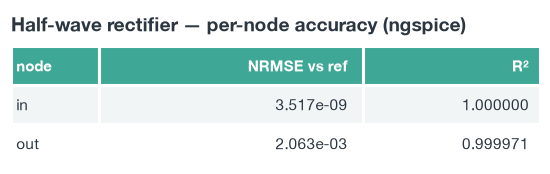

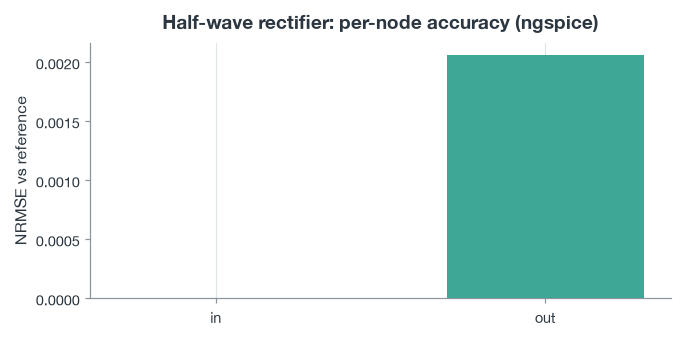

In [2]:
nodes  = [p["node"] for p in val.per_node]
nrmses = [p["nrmse"] for p in val.per_node]
for p in val.per_node:
    print("  %-6s NRMSE %.3e   R^2 %.6f" % (p["node"], p["nrmse"], p["r2"]))

# Per-node accuracy table.
table(
    ["node", "NRMSE vs ref", "R²"],
    [(p["node"], "%.3e" % p["nrmse"], "%.6f" % p["r2"]) for p in val.per_node],
    title="Half-wave rectifier — per-node accuracy (%s)" % val.reference_engine,
)
plt.show()

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.bar(nodes, nrmses, color=PALETTE["teal"], width=0.6, zorder=3)
ax.set_ylabel("NRMSE vs reference")
ax.set_title("Half-wave rectifier: per-node accuracy (%s)" % val.reference_engine)
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout(); plt.show()


A worst-node NRMSE in the low 1e-3 against an independent engine is a tight
agreement for a nonlinear circuit solved by harmonic balance. To validate your
*own* circuit against your *own* reference, just point `validate(ref=...)` at
any LTspice or ngspice `.raw`.